In [434]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

In [435]:
# Load cleaned dataset
df = pd.read_pickle('df_cleaned.pkl')

print(f"Dataset shape: {df.shape}")

# Separate features and labels
if 'Label' in df.columns:
    X = df.drop('Label', axis=1)
    y = df['Label']
    print(f"\nLabel column found")
    print(f"Label distribution:")
    print(y.value_counts())
else:
    X = df
    y = None
    print("\nNo Label column found")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Dataset shape: (610794, 8)

Label column found
Label distribution:
Label
BENIGN              417035
DoS Hulk            172849
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Heartbleed              11
Name: count, dtype: int64

Feature matrix shape: (610794, 7)
Number of samples: 610794
Number of features: 7


In [436]:
"""
DATA PREPROCESSING: SCALING
"""

# 1. Identify feature types
# Binary features usually only have 2 unique values
binary_features = [col for col in X.columns if X[col].nunique() <= 2]
continuous_features = [col for col in X.columns if col not in binary_features]

# 2. Log-transform ONLY skewed continuous features
skewed_cont = [col for col in continuous_features if X[col].skew() > 1]
X[skewed_cont] = np.log1p(X[skewed_cont])

# 3. Clean NaN/Inf
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# 4. Scale Continuous and Binary features differently
# RobustScaler for continuous
scaler_robust = RobustScaler()
X[continuous_features] = scaler_robust.fit_transform(X[continuous_features])

# MinMaxScaler for binary (forces them to be exactly 0 and 1)
scaler_minmax = MinMaxScaler()
X[binary_features] = scaler_minmax.fit_transform(X[binary_features])

# Convert back to numpy for your print loop
X_scaled = X.values

print(f"Scaled Data Shape: {X_scaled.shape}")
for i, feature in enumerate(X.columns):
    col_data = X_scaled[:, i]
    iqr = np.percentile(col_data, 75) - np.percentile(col_data, 25)
    print(f"Feature: {feature:25} | Median: {np.median(col_data):.1f} | IQR: {iqr:.1f}")

Scaled Data Shape: (610794, 7)
Feature: Destination Port          | Median: 0.0 | IQR: 1.0
Feature: Flow Duration             | Median: 0.0 | IQR: 1.0
Feature: Bwd Packet Length Max     | Median: 0.0 | IQR: 1.0
Feature: Bwd Packet Length Min     | Median: 0.0 | IQR: 1.0
Feature: Flow IAT Mean             | Median: 0.0 | IQR: 1.0
Feature: FIN Flag Count            | Median: 0.0 | IQR: 0.0
Feature: ACK Flag Count            | Median: 0.0 | IQR: 1.0


In [437]:
"""
DIMENSIONALITY REDUCTION: PCA
"""

# Automatic component selection
pca_full = PCA(n_components=0.95, whiten=True, random_state=42)
X_pca = pca_full.fit_transform(X_scaled)

print(f"\nPCA components retained: {X_pca.shape[1]}")
print(f"Total explained variance: {pca_full.explained_variance_ratio_.sum():.2%}")

# Scree plot (real one)
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_scree.png", dpi=120)
plt.close()

# 2D projection (visual only)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

explained_2d = pca_2d.explained_variance_ratio_
print(f"PCA 2D variance: {explained_2d.sum():.2%}")


PCA components retained: 5
Total explained variance: 95.53%
PCA 2D variance: 79.80%


In [438]:
"""
CLUSTERING: K-MEANS
"""

rng = np.random.default_rng(42)

# Sampling
n_samples = X_pca.shape[0]
sample_size = min(100000, n_samples)

idx = rng.choice(n_samples, sample_size, replace=False)
X_sample = X_pca[idx]

# Train / Eval split
eval_size = min(20000, sample_size // 3)

perm = rng.permutation(sample_size)
X_fit = X_sample[perm[:-eval_size]]
X_eval = X_sample[perm[-eval_size:]]

# Wider k search
k_values = range(2, 6)

results = []

print(f"K-Means Evaluation (fit={len(X_fit)}, eval={len(X_eval)}):")
print(f"{'k':<4} {'Sil':<8} {'DB':<8} {'Inertia':<12}")
print("-" * 45)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=20,
        max_iter=500,
        random_state=42
    )
    
    model.fit(X_fit)
    labels = model.predict(X_eval)

    sil = silhouette_score(X_eval, labels)
    db = davies_bouldin_score(X_eval, labels)

    results.append({
        "k": k,
        "model": model,
        "sil": sil,
        "db": db,
        "inertia": model.inertia_
    })

    print(f"{k:<4} {sil:<8.4f} {db:<8.4f} {model.inertia_:<12.2e}")

# Selection
df_k = pd.DataFrame(results)

kmeans_results = {
    row["k"]: {
        "model": row["model"],
        "sil": row["sil"],
        "db": row["db"],
        "inertia": row["inertia"],
        "silhouette": row["sil"],
        "davies_bouldin": row["db"]
    }
    for row in results
}

# Rule:
# 1. Max silhouette
# 2. Tie-break: lower DB
best = df_k.sort_values(
    by=["sil", "db"],
    ascending=[False, True]
).iloc[0]

optimal_k = int(best["k"])
best_model = best["model"]

kmeans_optimal_labels = best_model.predict(X_pca)

print(f"\nOptimal k: {optimal_k}")
print(f"Silhouette: {best['sil']:.4f}")
print(f"Davies-Bouldin: {best['db']:.4f}")
print(f"Inertia: {best['inertia']:.2e}")

K-Means Evaluation (fit=80000, eval=20000):
k    Sil      DB       Inertia     
---------------------------------------------
2    0.2743   1.8820   3.22e+05    
3    0.3691   1.4605   2.48e+05    
4    0.4531   1.0803   1.82e+05    
5    0.5644   0.8849   1.26e+05    

Optimal k: 5
Silhouette: 0.5644
Davies-Bouldin: 0.8849
Inertia: 1.26e+05


In [439]:
"""
K-MEANS EVALUATION METRICS
"""

# Sort safely
k_list = sorted(kmeans_results.keys())

# Build aligned arrays (robust)
inertias = [kmeans_results[k]["inertia"] for k in k_list]
silhouettes = [kmeans_results[k]["silhouette"] for k in k_list]
db_indices = [kmeans_results[k]["davies_bouldin"] for k in k_list]

# Best indices
best_sil_k = max(kmeans_results, key=lambda k: kmeans_results[k]["silhouette"])
best_db_k = min(kmeans_results, key=lambda k: kmeans_results[k]["davies_bouldin"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Inertia (Elbow)
axes[0].plot(k_list, inertias, marker='o')
axes[0].axvline(optimal_k, linestyle='--', label=f"k={optimal_k}")
axes[0].set_title("Elbow Method (Inertia)", fontweight='bold')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(k_list, silhouettes, marker='o')
axes[1].axvline(best_sil_k, linestyle='--', label=f"best={best_sil_k}")
axes[1].set_title("Silhouette Score", fontweight='bold')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Davies-Bouldin
axes[2].plot(k_list, db_indices, marker='o')
axes[2].axvline(best_db_k, linestyle='--', label=f"best={best_db_k}")
axes[2].set_title("Davies-Bouldin Index", fontweight='bold')
axes[2].set_xlabel("k")
axes[2].set_ylabel("Index (lower is better)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_evaluation.png", dpi=120, bbox_inches="tight")
plt.close()

print("K-Means evaluation metrics saved")

K-Means evaluation metrics saved


In [440]:
"""
HIERARCHICAL CLUSTERING
"""

linkage_criteria = ['ward', 'complete', 'average']

hc_results = {}

# Sampling
hc_sample_size = min(10000, X_pca.shape[0])
hc_idx = np.random.choice(X_pca.shape[0], hc_sample_size, replace=False)
X_hc_sample = X_pca[hc_idx]

print(f"\nHierarchical Clustering (sample={hc_sample_size}, k={optimal_k})")
print(f"{'Linkage':<10} {'Sil':<10} {'DB':<10}")
print("-" * 35)

# Fit + evaluate
for linkage in linkage_criteria:

    model = AgglomerativeClustering(
        n_clusters=optimal_k,
        linkage=linkage
    )

    labels = model.fit_predict(X_hc_sample)

    sil = silhouette_score(X_hc_sample, labels)
    db = davies_bouldin_score(X_hc_sample, labels)

    hc_results[linkage] = {
        "model": model,
        "labels": labels,
        "sil": sil,
        "db": db
    }

    print(f"{linkage:<10} {sil:<10.4f} {db:<10.4f}")

# Selection
best_linkage = max(
    hc_results,
    key=lambda k: (
        hc_results[k]["sil"] - hc_results[k]["db"]  # simple but stable trade-off
    )
)

best_hc_linkage = best_linkage
best_model = hc_results[best_linkage]["model"]
hc_optimal_labels = hc_results[best_linkage]["labels"]

# Propagate sample-based hierarchical labels to the full dataset for consistent visualization.
knn = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
knn.fit(X_hc_sample, hc_optimal_labels)
hc_optimal_labels = knn.predict(X_pca)

print(f"\nBest linkage: {best_linkage}")
print(f"Silhouette: {hc_results[best_linkage]['sil']:.4f}")
print(f"Davies-Bouldin: {hc_results[best_linkage]['db']:.4f}")


Hierarchical Clustering (sample=10000, k=5)
Linkage    Sil        DB        
-----------------------------------
ward       0.5618     0.8937    
complete   0.3034     1.4502    
average    0.2773     0.8749    

Best linkage: ward
Silhouette: 0.5618
Davies-Bouldin: 0.8937


In [441]:
"""
VISUALIZATION: Hierarchical Clustering
"""

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=hc_optimal_labels,
    cmap='viridis',
    s=20,
    alpha=0.75
)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')

ax.set_title(
    f'Hierarchical Clustering ({best_hc_linkage})\n'
    f'2D PCA projection of high-dimensional clusters',
    fontsize=12,
    fontweight='bold'
)

plt.colorbar(sc, ax=ax, label='Cluster ID')

plt.tight_layout()
plt.savefig('hierarchical_clustering.png', dpi=120, bbox_inches='tight')
plt.close()

print("Hierarchical clustering visualization saved")

Hierarchical clustering visualization saved


In [442]:
"""
DBSCAN CLUSTERING
"""

rng = np.random.default_rng(42)

sample_size = min(10000, X_pca.shape[0])
idx = rng.choice(X_pca.shape[0], sample_size, replace=False)
X_db = X_pca[idx]
y_db = y.iloc[idx] if y is not None else None

# k-distance for eps - use lower k for more connectivity
k = 5  
nn = NearestNeighbors(n_neighbors=k).fit(X_db)
distances, _ = nn.kneighbors(X_db)
k_dist = np.sort(distances[:, -1])

# Choose eps_values and min_samples 
eps_values = [0.5, 0.7, 0.9, 1.1]  # Adjusted for high-dimensional data
min_samples_values = [5, 10, 15]  # Lower than typical to allow more clusters in high dimensions

results = []

for eps in eps_values:
    for ms in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_db)

        # Number of clusters (excluding noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = np.mean(labels == -1)

        mask = labels != -1

        if n_clusters < 2 or np.sum(mask) < 10:
            continue

        sil = silhouette_score(X_db[mask], labels[mask])
        db = davies_bouldin_score(X_db[mask], labels[mask])

        results.append([eps, ms, n_clusters, noise, sil, db])
        print(f"eps={eps:.3f} min_samples={ms:<3} clusters={n_clusters:<3} noise={noise:.2%} sil={sil:.3f} db={db:.3f}")

df = pd.DataFrame(results, columns=["eps","min_samples","clusters","noise","sil","db"])

# Prefer lower-noise options with a reasonable number of clusters
df_valid = df[
    (df["noise"].between(0.05, 0.50)) &
    (df["clusters"].between(2, 6))
]

if len(df_valid) == 0:
    df_valid = df

df_valid["score"] = df_valid["sil"] - 0.5 * df_valid["db"]

best_dbscan = df_valid.sort_values(
    by="score",
    ascending=False
).iloc[0]

best_eps, best_ms = best_dbscan["eps"], int(best_dbscan["min_samples"])
best_min_samples = best_ms

# Fit the best DBSCAN model on the sampled data and keep the same 2D PCA projection.
dbscan_optimal_labels = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit_predict(X_db)
X_pca_2d_db = X_pca_2d[idx]

n_dbscan_clusters = len(set(dbscan_optimal_labels)) - (1 if -1 in dbscan_optimal_labels else 0)
n_dbscan_noise = np.sum(dbscan_optimal_labels == -1)

# Propagate DBSCAN labels to full dataset
knn_db_full = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_db_full.fit(X_db, dbscan_optimal_labels)
dbscan_full_labels = knn_db_full.predict(X_pca)

n_dbscan_full_clusters = len(set(dbscan_full_labels)) - (1 if -1 in dbscan_full_labels else 0)

n_dbscan_full_noise = np.sum(dbscan_full_labels == -1)

print(f"sample clusters={n_dbscan_clusters}, sample noise={n_dbscan_noise/len(dbscan_optimal_labels):.1%}")
print(f"full clusters={n_dbscan_full_clusters}, full noise={n_dbscan_full_noise/len(dbscan_full_labels):.1%}")

print(f"\nBEST DBSCAN: eps={best_eps:.3f}, min_samples={best_min_samples}")

eps=0.500 min_samples=5   clusters=43  noise=1.34% sil=0.527 db=0.602
eps=0.500 min_samples=10  clusters=27  noise=2.60% sil=0.564 db=0.625
eps=0.500 min_samples=15  clusters=21  noise=3.32% sil=0.581 db=0.667
eps=0.700 min_samples=5   clusters=32  noise=0.85% sil=0.509 db=0.612
eps=0.700 min_samples=10  clusters=25  noise=1.49% sil=0.525 db=0.587
eps=0.700 min_samples=15  clusters=19  noise=2.55% sil=0.540 db=0.528
eps=0.900 min_samples=5   clusters=20  noise=0.43% sil=0.411 db=0.743
eps=0.900 min_samples=10  clusters=15  noise=0.92% sil=0.568 db=0.711
eps=0.900 min_samples=15  clusters=15  noise=1.24% sil=0.599 db=0.723
eps=1.100 min_samples=5   clusters=12  noise=0.32% sil=0.309 db=0.731
eps=1.100 min_samples=10  clusters=9   noise=0.54% sil=0.333 db=0.796
eps=1.100 min_samples=15  clusters=8   noise=0.67% sil=0.388 db=0.808
sample clusters=19, sample noise=2.5%
full clusters=19, full noise=2.5%

BEST DBSCAN: eps=0.700, min_samples=15


In [443]:
"""
BUILD COMPARISON TABLE
"""

# Safe extraction

# K-Means
kmeans_info = kmeans_results.get(optimal_k)

if kmeans_info is None and 'df_k' in globals():
    km_row = df_k.loc[df_k['k'] == optimal_k]
    if len(km_row) == 1:
        kmeans_info = {
            "sil": km_row.iloc[0]["sil"],
            "db": km_row.iloc[0]["db"],
            "silhouette": km_row.iloc[0]["sil"],
            "davies_bouldin": km_row.iloc[0]["db"]
        }

if kmeans_info is None:
    kmeans_info = {"sil": np.nan, "db": np.nan}
kmeans_sil = kmeans_info.get("sil", kmeans_info.get("silhouette", np.nan))
kmeans_db = kmeans_info.get("db", kmeans_info.get("davies_bouldin", np.nan))

# Hierarchical
hc_sil = hc_results[best_hc_linkage]["sil"]
hc_db = hc_results[best_hc_linkage]["db"]

# DBSCAN
# Use the already computed sample-based DBSCAN metrics instead of expensive full-data recomputation.
dbscan_labels = dbscan_full_labels

dbscan_sil = float(best_dbscan["sil"]) if "best_dbscan" in globals() else np.nan
dbscan_db = float(best_dbscan["db"]) if "best_dbscan" in globals() else np.nan

dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Build table
comparison_df = pd.DataFrame({
    "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
    "Parameters": [
        f"k={optimal_k}",
        f"linkage={best_hc_linkage}",
        f"eps={best_eps:.3f}, min_samples={best_min_samples}"
    ],
    "N_Clusters": [
        optimal_k,
        optimal_k,
        dbscan_clusters
    ],
    "Silhouette": [
        kmeans_sil,
        hc_sil,
        dbscan_sil
    ],

    "Davies-Bouldin": [
        kmeans_db,
        hc_db,
        dbscan_db
    ]
})

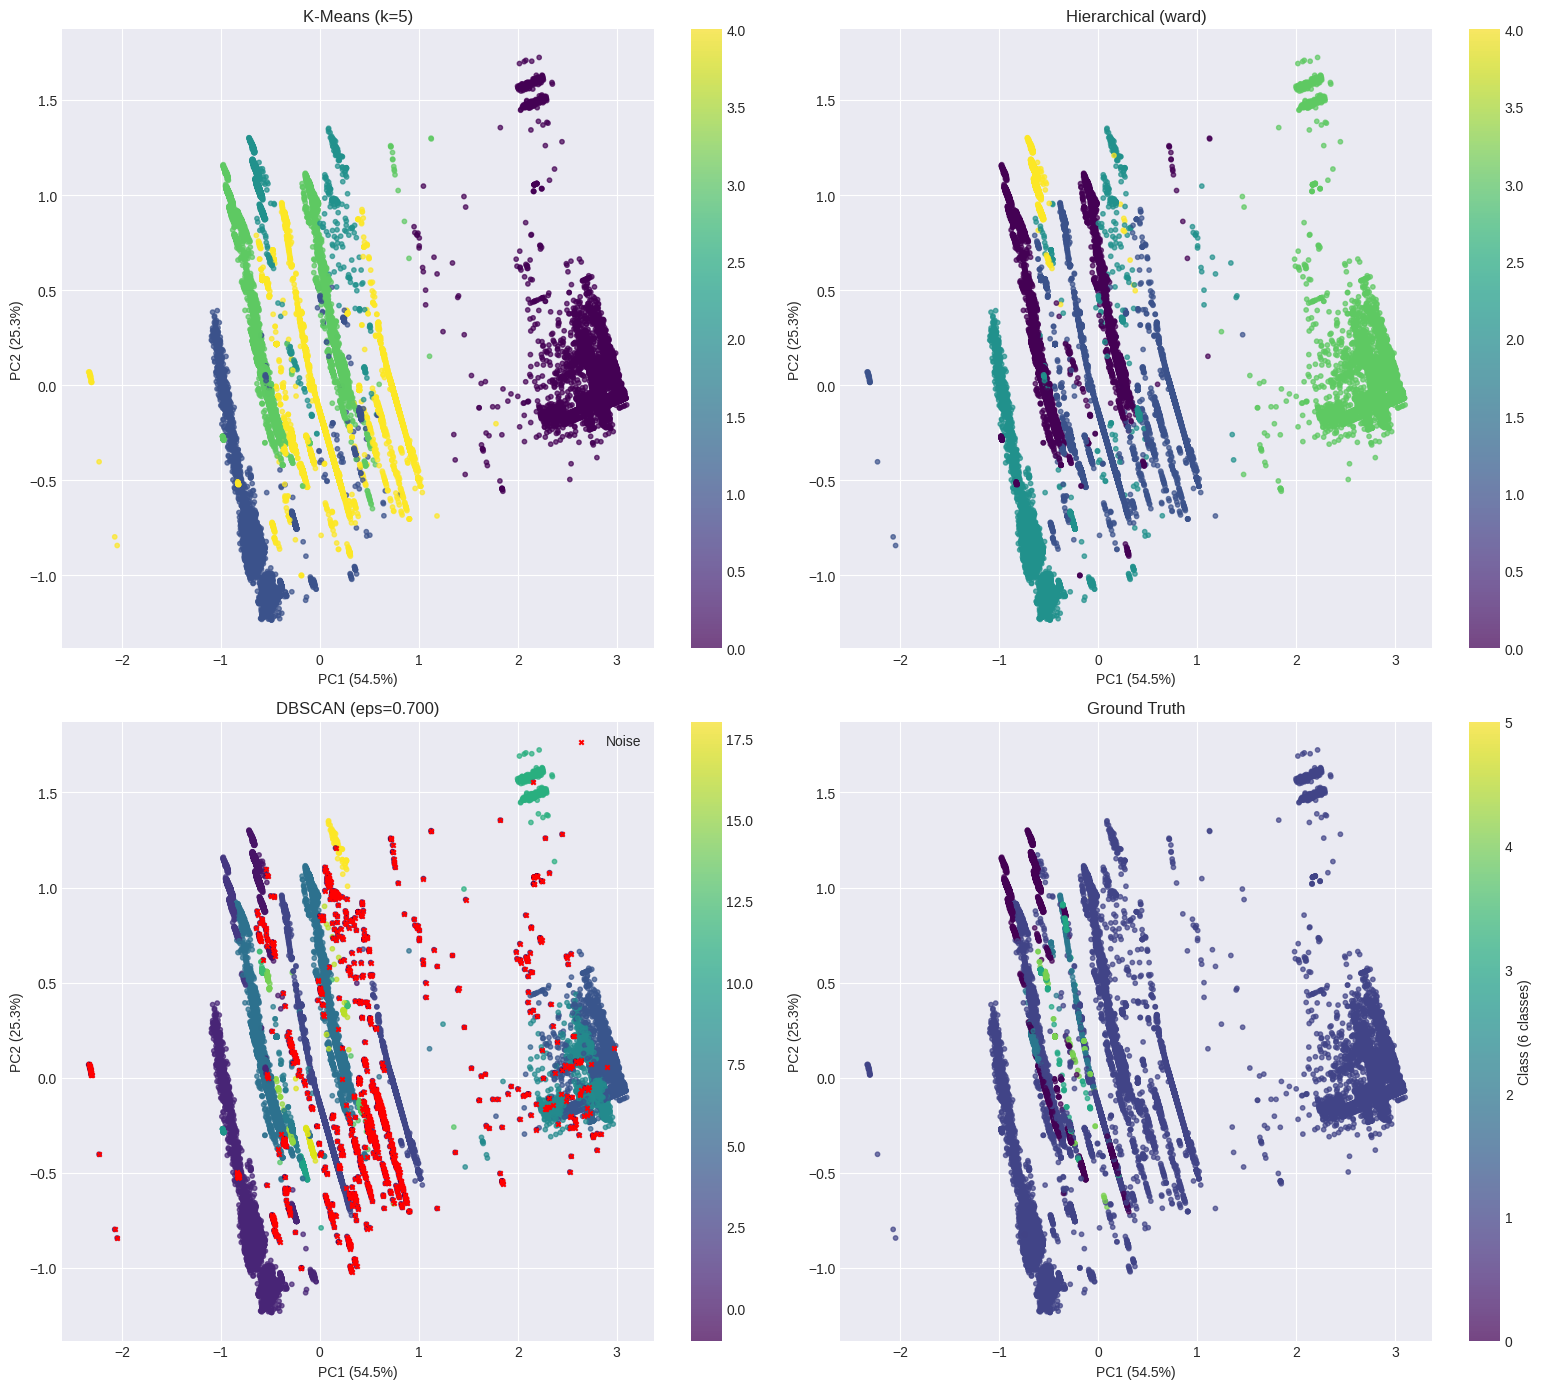

In [444]:
"""
VISUALIZATION: 4-Panel Comparison
"""

# For consistent visualization, use the same sample for all algorithms
viz_sample_size = min(50000, X_pca.shape[0])  # Reasonable size for visualization
viz_rng = np.random.default_rng(123)  # Different seed for viz sample
viz_idx = viz_rng.choice(X_pca.shape[0], viz_sample_size, replace=False)
X_pca_2d_viz = X_pca_2d[viz_idx]

# Get labels for the visualization sample
kmeans_viz_labels = kmeans_optimal_labels[viz_idx]
hc_viz_labels = hc_optimal_labels[viz_idx]

# Use full DBSCAN propagation labels for visualization
dbscan_viz_labels = dbscan_full_labels[viz_idx]

# Ground truth for visualization sample
if y is not None:
    y_viz = y.iloc[viz_idx] if hasattr(y, 'iloc') else y[viz_idx]
    y_viz_enc, _ = pd.factorize(y_viz)
    n_classes = len(np.unique(y_viz_enc))
else:
    y_viz_enc = None

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

pca_var1 = pca_2d.explained_variance_ratio_[0]
pca_var2 = pca_2d.explained_variance_ratio_[1]

# K-MEANS
sc1 = axes[0, 0].scatter(
    X_pca_2d_viz[:, 0],
    X_pca_2d_viz[:, 1],
    c=kmeans_viz_labels,
    cmap='viridis',
    s=10,
    alpha=0.7
)

axes[0, 0].set_title(f"K-Means (k={optimal_k})")
axes[0, 0].set_xlabel(f"PC1 ({pca_var1:.1%})")
axes[0, 0].set_ylabel(f"PC2 ({pca_var2:.1%})")
plt.colorbar(sc1, ax=axes[0, 0])

# HIERARCHICAL
sc2 = axes[0, 1].scatter(
    X_pca_2d_viz[:, 0],
    X_pca_2d_viz[:, 1],
    c=hc_viz_labels,
    cmap='viridis',
    s=10,
    alpha=0.7
)

axes[0, 1].set_title(f"Hierarchical ({best_hc_linkage})")
axes[0, 1].set_xlabel(f"PC1 ({pca_var1:.1%})")
axes[0, 1].set_ylabel(f"PC2 ({pca_var2:.1%})")
plt.colorbar(sc2, ax=axes[0, 1])

# DBSCAN
sc3 = axes[1, 0].scatter(
    X_pca_2d_viz[:, 0],
    X_pca_2d_viz[:, 1],
    c=dbscan_viz_labels,
    cmap='viridis',
    s=10,
    alpha=0.7
)

noise_mask = dbscan_viz_labels == -1
axes[1, 0].scatter(
    X_pca_2d_viz[noise_mask, 0],
    X_pca_2d_viz[noise_mask, 1],
    c='red',
    s=10,
    marker='x',
    label='Noise'
)

axes[1, 0].set_title(f"DBSCAN (eps={best_eps:.3f})")
axes[1, 0].set_xlabel(f"PC1 ({pca_var1:.1%})")
axes[1, 0].set_ylabel(f"PC2 ({pca_var2:.1%})")
axes[1, 0].legend()
plt.colorbar(sc3, ax=axes[1, 0])

# GROUND TRUTH
if y_viz_enc is not None:
    sc4 = axes[1, 1].scatter(
        X_pca_2d_viz[:, 0],
        X_pca_2d_viz[:, 1],
        c=y_viz_enc,
        cmap='viridis',
        s=10,
        alpha=0.7,
        vmin=0,
        vmax=n_classes-1
    )

    axes[1, 1].set_title("Ground Truth")
    axes[1, 1].set_xlabel(f"PC1 ({pca_var1:.1%})")
    axes[1, 1].set_ylabel(f"PC2 ({pca_var2:.1%})")
    cbar = plt.colorbar(sc4, ax=axes[1, 1])
    cbar.set_label(f"Class ({n_classes} classes)")
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig("algorithms_comparison.png", dpi=120)
plt.show()

In [445]:
"""
EXTERNAL VALIDATION: Compare with Ground Truth
"""

if y is not None:

    # Align all predictions
    y_true = y  # MUST match all model outputs

    k_pred = kmeans_optimal_labels
    h_pred = hc_optimal_labels
    d_pred = dbscan_full_labels

    # Metrics
    ext = pd.DataFrame({
        "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
        "ARI": [
            adjusted_rand_score(y_true, k_pred),
            adjusted_rand_score(y_true, h_pred),
            adjusted_rand_score(y_true, d_pred)
        ],

        "NMI": [
            normalized_mutual_info_score(y_true, k_pred),
            normalized_mutual_info_score(y_true, h_pred),
            normalized_mutual_info_score(y_true, d_pred)
        ]
    })

    print(ext.to_string(index=False))

    # Contingency tables
    print("\nK-Means vs Ground Truth")
    print(pd.crosstab(y_true, k_pred))

    print("\nHierarchical vs Ground Truth")
    print(pd.crosstab(y_true, h_pred))

    print("\nDBSCAN vs Ground Truth")
    print(pd.crosstab(y_true, d_pred))
else:
    print("\nNo ground truth labels available for external validation.")


   Algorithm      ARI      NMI
     K-Means 0.214117 0.327266
Hierarchical 0.219317 0.341027
      DBSCAN 0.240522 0.388245

K-Means vs Ground Truth
col_0                 0       1      2      3      4
Label                                               
BENIGN            81700  195945   2999  90659  45732
DoS GoldenEye         0       0     44   7334   2908
DoS Hulk              0       3  89875  64996  17975
DoS Slowhttptest      0       2    313      7   4906
DoS slowloris         0       0    138      6   5241
Heartbleed            0       0     10      1      0

Hierarchical vs Ground Truth
col_0                 0      1       2      3      4
Label                                               
BENIGN            90993  46348  197917  81493    284
DoS GoldenEye      7358   2578     350      0      0
DoS Hulk          65131  17975       3      0  89740
DoS Slowhttptest    320   4906       2      0      0
DoS slowloris       154   5231       0      0      0
Heartbleed            2   

In [446]:
"""
SUMMARY REPORT
"""

best_sil_algo = comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Algorithm']
best_sil_val = comparison_df['Silhouette'].max()
best_db_algo = comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin(), 'Algorithm']
best_db_val = comparison_df['Davies-Bouldin'].min()

print(f"""
DATA & PCA:
  • Samples: {X_scaled.shape[0]:,}, Features: {X_scaled.shape[1]}
  • PCA (Full): {X_pca.shape[1]} components
  • PCA 2D Variance: {pca_2d.explained_variance_ratio_.sum():.2%}

K-MEANS (k={optimal_k}):
  • Silhouette: {comparison_df.loc[0, 'Silhouette']:.4f}
  • Davies-Bouldin: {comparison_df.loc[0, 'Davies-Bouldin']:.4f}

HIERARCHICAL ({best_hc_linkage}):
  • Silhouette: {comparison_df.loc[1, 'Silhouette']:.4f}
  • Davies-Bouldin: {comparison_df.loc[1, 'Davies-Bouldin']:.4f}

DBSCAN (eps={best_eps:.3f}, min_samples={best_min_samples}):
  • Clusters: {n_dbscan_full_clusters}
  • Noise: {n_dbscan_full_noise} ({n_dbscan_full_noise/len(dbscan_full_labels)*100:.1f}%)
  • Silhouette: {comparison_df.loc[2, 'Silhouette']:.4f}
  • Davies-Bouldin: {comparison_df.loc[2, 'Davies-Bouldin']:.4f}

BEST PERFORMERS:
  • By Silhouette: {best_sil_algo} ({best_sil_val:.4f})
  • By Davies-Bouldin: {best_db_algo} ({best_db_val:.4f})
""")


DATA & PCA:
  • Samples: 610,794, Features: 7
  • PCA (Full): 5 components
  • PCA 2D Variance: 79.80%

K-MEANS (k=5):
  • Silhouette: 0.5644
  • Davies-Bouldin: 0.8849

HIERARCHICAL (ward):
  • Silhouette: 0.5618
  • Davies-Bouldin: 0.8937

DBSCAN (eps=0.700, min_samples=15):
  • Clusters: 19
  • Noise: 15352 (2.5%)
  • Silhouette: 0.5396
  • Davies-Bouldin: 0.5278

BEST PERFORMERS:
  • By Silhouette: K-Means (0.5644)
  • By Davies-Bouldin: DBSCAN (0.5278)

